# Piloto Semana 4 — Evaluación final sobre test (P10, uso único)

Notebook modular, cuarto y último del piloto. Usa la porción `test` de
`dataset_split_piloto.csv` (generada por `01_Adquisicion_EDA.ipynb`, nunca tocada por
`02_Piloto_Baseline_RegresionLogistica.ipynb` ni `03_Piloto_RandomForest.ipynb`, que solo
usaron train/val).

**Regla que se ejercita aquí (Protocolo v2.1 §11, P04 y P10):**

> El conjunto de prueba no se usa para selección de variables, ajuste de
> hiperparámetros, ni selección de modelo — solo para la evaluación final única.
> Cualquier ajuste posterior a esta evaluación no puede volver a tocar el test;
> regresa a validación.

Como esto es el **test piloto** (de la muestra reducida de 1200 filas, no el test
oficial de Fase 5, que todavía no existe), tocarlo aquí no gasta ningún recurso real de
la tesis — el objetivo es demostrar que el mecanismo de "evaluación final única" se
puede ejecutar correctamente, antes de que importe de verdad.

**⚠️ Este notebook se ejecuta una sola vez con los modelos ya fijados (mismos
hiperparámetros que 02 y 03, sin ningún ajuste adicional).** Si después de verlo hiciera
falta cambiar algo del modelo, la corrección se hace sobre validación (02/03), **no** se
vuelve a correr este notebook con cambios — eso sería romper la regla P10 incluso a
nivel piloto, y el piloto existe justamente para practicar no hacer eso.

**Evidencia que produce:** `metricas_test_piloto.json` y `matriz_confusion_test.png`
dentro de `evidencias/baseline_regresion_logistica/` y `evidencias/random_forest/`, más
`evidencias/comparacion_test_piloto.csv` con ambos modelos lado a lado.


In [1]:
import csv
import json
import platform
import time
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import psutil
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.preprocessing import StandardScaler

SEED = 42
TARGET_COL = "Target"


## 0. Entorno y rutas (mismo detector que los notebooks 01-03)

In [2]:
_entorno_detectado = {
    "Linux": "laptop_arch_linux",
    "Windows": "escritorio_windows10",
}.get(platform.system(), "entorno_no_reconocido")

RUTA_EVIDENCIAS_PILOTO = Path(f"../../Pilotaje/{_entorno_detectado}/evidencias")
RUTA_BASELINE = RUTA_EVIDENCIAS_PILOTO / "baseline_regresion_logistica"
RUTA_RF = RUTA_EVIDENCIAS_PILOTO / "random_forest"
RUTA_BASELINE.mkdir(parents=True, exist_ok=True)
RUTA_RF.mkdir(parents=True, exist_ok=True)
RUTA_BITACORA = Path(f"../../Pilotaje/{_entorno_detectado}/bitacora_ejecucion.csv")

_proceso = psutil.Process()


def _siguiente_contador():
    """Continúa la numeración P-01, P-02... donde la haya dejado el último notebook
    que escribió en esta bitácora (01, 02, 03 o 04)."""
    if RUTA_BITACORA.exists() and RUTA_BITACORA.stat().st_size > 0:
        with open(RUTA_BITACORA, newline="", encoding="utf-8") as f:
            ids = [fila["id"] for fila in csv.DictReader(f)]
        numeros = [int(i.split("-")[1]) for i in ids if i.startswith("P-")]
        return max(numeros) if numeros else 0
    return 0


_contador_pasos = [_siguiente_contador()]


class registrar_paso:
    """Igual que en los otros notebooks del piloto: mide tiempo y memoria (RSS, vía
    psutil, cross-platform) de un bloque y lo agrega a la bitácora compartida."""

    def __init__(self, accion, entrada, esperado, evidencia=""):
        self.accion, self.entrada, self.esperado, self.evidencia = accion, entrada, esperado, evidencia

    def __enter__(self):
        self.t0 = time.perf_counter()
        self.mem_inicio_mb = _proceso.memory_info().rss / 1024**2
        return self

    def __exit__(self, exc_type, exc_val, exc_tb):
        _contador_pasos[0] += 1
        duracion = round(time.perf_counter() - self.t0, 3)
        mem_fin_mb = _proceso.memory_info().rss / 1024**2
        delta_mem_mb = round(mem_fin_mb - self.mem_inicio_mb, 1)
        observado = "OK" if exc_type is None else f"ERROR: {exc_val}"
        incidencia = "" if exc_type is None else str(exc_val)
        fila = {
            "id": f"P-{_contador_pasos[0]:02d}",
            "accion": self.accion,
            "entrada": self.entrada,
            "esperado": self.esperado,
            "observado": f"{observado} | tiempo={duracion}s | rss_actual={round(mem_fin_mb, 1)}MB | delta_mem={delta_mem_mb}MB",
            "incidencia": incidencia,
            "evidencia": self.evidencia,
        }
        existe_con_contenido = RUTA_BITACORA.exists() and RUTA_BITACORA.stat().st_size > 0
        with open(RUTA_BITACORA, "a", newline="", encoding="utf-8") as f:
            w = csv.DictWriter(f, fieldnames=list(fila.keys()))
            if not existe_con_contenido:
                w.writeheader()
            w.writerow(fila)
        print(f"[{fila['id']}] {self.accion} -> {fila['observado']}")
        return False


print(f"Entorno detectado: {_entorno_detectado}")


Entorno detectado: laptop_arch_linux


## 1. Cargar train y test de la partición piloto

Primera y única vez que este test se usa en todo el piloto — `02` y `03` solo tocaron
`train`/`val`.

In [3]:
df_split_piloto = pd.read_csv(RUTA_EVIDENCIAS_PILOTO / "dataset_split_piloto.csv")

cols_features_piloto = [c for c in df_split_piloto.columns if c not in {TARGET_COL, "class_binaria", "split"}]

df_train_piloto = df_split_piloto[df_split_piloto["split"] == "train"]
df_test_piloto = df_split_piloto[df_split_piloto["split"] == "test"]

X_train_piloto = df_train_piloto[cols_features_piloto]
y_train_piloto = df_train_piloto["class_binaria"]
X_test_piloto = df_test_piloto[cols_features_piloto]
y_test_piloto = df_test_piloto["class_binaria"]

print(f"train={len(X_train_piloto)}  test={len(X_test_piloto)}  variables={len(cols_features_piloto)}")


train=840  test=180  variables=36


## 2. Reentrenar ambos modelos sobre train (determinista — mismos seed e
hiperparámetros que 02 y 03, da exactamente el mismo modelo, solo que ahora se evalúa
sobre test en vez de val)

In [4]:
with registrar_paso(
    accion="Reajustar pipeline (StandardScaler + SMOTE) y reentrenar baseline y Random Forest sobre train",
    entrada=f"train piloto ({len(X_train_piloto)} filas)",
    esperado="mismos modelos que 02/03 (determinista, mismo seed); ningún ajuste nuevo de hiperparámetros",
    evidencia="(reentrenamiento interno, sin archivo propio -- la evidencia es la evaluación de la sección 3)",
):
    escalador = StandardScaler()
    X_train_escalado = escalador.fit_transform(X_train_piloto)
    X_train_proc, y_train_proc = SMOTE(random_state=SEED).fit_resample(X_train_escalado, y_train_piloto)
    X_test_proc = escalador.transform(X_test_piloto)

    modelos = {
        "baseline_regresion_logistica": LogisticRegression(max_iter=1000, random_state=SEED),
        "random_forest": RandomForestClassifier(random_state=SEED),
    }
    for modelo in modelos.values():
        modelo.fit(X_train_proc, y_train_proc)

print("Modelos reentrenados:", list(modelos.keys()))


[P-09] Reajustar pipeline (StandardScaler + SMOTE) y reentrenar baseline y Random Forest sobre train -> OK | tiempo=0.197s | rss_actual=240.6MB | delta_mem=5.6MB
Modelos reentrenados: ['baseline_regresion_logistica', 'random_forest']


## 3. Evaluación final sobre test — ÚNICA VEZ (P10)

A partir de acá, **no se vuelve a tocar `X_test_proc`/`y_test_piloto` en este ni en
ningún otro notebook del piloto.** Si algo necesita ajustarse, se vuelve a `02`/`03`
sobre validación.

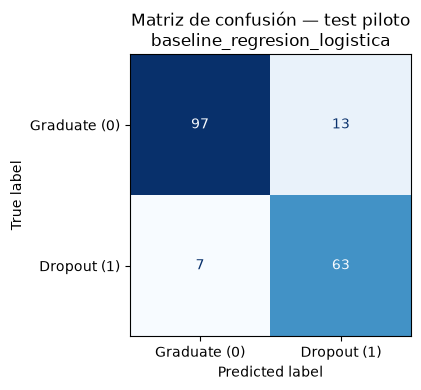

baseline_regresion_logistica -> {'auc_roc': 0.9301, 'f1': 0.863, 'precision': 0.8289, 'recall': 0.9, 'exactitud': 0.8889, 'n_test': 180}


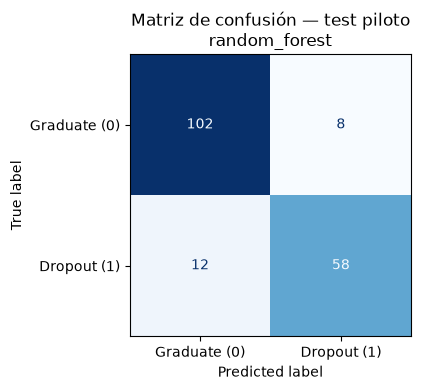

random_forest -> {'auc_roc': 0.9451, 'f1': 0.8529, 'precision': 0.8788, 'recall': 0.8286, 'exactitud': 0.8889, 'n_test': 180}
[P-10] Evaluar ambos modelos sobre test piloto (única vez) y guardar métricas + matriz de confusión -> OK | tiempo=0.335s | rss_actual=249.5MB | delta_mem=8.9MB


In [5]:
RUTAS_POR_MODELO = {
    "baseline_regresion_logistica": RUTA_BASELINE,
    "random_forest": RUTA_RF,
}

resultados_test = {}

with registrar_paso(
    accion="Evaluar ambos modelos sobre test piloto (única vez) y guardar métricas + matriz de confusión",
    entrada=f"test piloto ({len(X_test_proc)} filas), 2 modelos ya entrenados",
    esperado="métricas y matriz de confusión calculadas y guardadas para cada modelo, sin re-tocar el test después",
    evidencia="metricas_test_piloto.json y matriz_confusion_test.png por modelo",
):
    for nombre, modelo in modelos.items():
        y_proba = modelo.predict_proba(X_test_proc)[:, 1]
        y_pred = modelo.predict(X_test_proc)

        metricas = {
            "auc_roc": round(float(roc_auc_score(y_test_piloto, y_proba)), 4),
            "f1": round(float(f1_score(y_test_piloto, y_pred)), 4),
            "precision": round(float(precision_score(y_test_piloto, y_pred)), 4),
            "recall": round(float(recall_score(y_test_piloto, y_pred)), 4),
            "exactitud": round(float(accuracy_score(y_test_piloto, y_pred)), 4),
            "n_test": int(len(y_test_piloto)),
        }
        resultados_test[nombre] = metricas

        ruta_modelo = RUTAS_POR_MODELO[nombre]
        with open(ruta_modelo / "metricas_test_piloto.json", "w", encoding="utf-8") as f:
            json.dump(metricas, f, indent=2, ensure_ascii=False)

        fig, ax = plt.subplots(figsize=(4.5, 4))
        ConfusionMatrixDisplay(
            confusion_matrix(y_test_piloto, y_pred), display_labels=["Graduate (0)", "Dropout (1)"]
        ).plot(ax=ax, cmap="Blues", colorbar=False)
        ax.set_title(f"Matriz de confusión — test piloto\n{nombre}")
        plt.tight_layout()
        plt.savefig(ruta_modelo / "matriz_confusion_test.png", dpi=150, bbox_inches="tight")
        plt.show()

        print(nombre, "->", metricas)


## 4. Comparación final sobre test (congelada, no se vuelve a recalcular)

In [6]:
comparacion_test = pd.DataFrame(resultados_test).T
comparacion_test.index.name = "modelo"
comparacion_test.to_csv(RUTA_EVIDENCIAS_PILOTO / "comparacion_test_piloto.csv")

comparacion_test


,auc_roc,f1,precision,recall,exactitud,n_test
modelo,,,,,,
baseline_regresion_logistica,0.9301,0.8630,0.8289,0.9000,0.8889,180.0
random_forest,0.9451,0.8529,0.8788,0.8286,0.8889,180.0


## 5. Cierre

El test piloto ya se usó. A partir de aquí:

- Si hiciera falta ajustar hiperparámetros, variables o preprocesamiento, el lugar para
  eso es `02`/`03` sobre **validación** — nunca reabrir este notebook para "ver cómo
  queda" con un cambio.
- Esta evaluación es **piloto, no oficial** — la evaluación real de la tesis (Fase 5,
  semana 11, Protocolo v2.1 §11 P10) se hace una sola vez sobre el test oficial
  (partición completa, 4 modelos ya ajustados con Optuna), y esa sí es la que cuenta
  para la tesis.
